In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
data = data.dropna()

In [4]:
exog_vars_train = data[["temp", "humidity", "winddir", "solarradiation"]][: -168]
exog_vars_test = data[["temp", "humidity", "winddir", "solarradiation"]][-168: ]
x_train = data["cloudcover"][: -168]
x_test = data["cloudcover"][-168: ]
x_train.shape, x_test.shape, exog_vars_train.shape, exog_vars_test.shape

((21534,), (168,), (21534, 4), (168, 4))

In [5]:
exog_vars_test.isna().sum()

temp              0
humidity          0
winddir           0
solarradiation    0
dtype: int64

In [6]:
model_sarima = SARIMAX(x_train, 
                       exog_vars_train,
                       order=(5, 1, 2), 
                       seasonal_order=(1, 1, 1, 24))
model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarni

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           14     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.49234D+00    |proj g|=  1.07915D-01

At iterate    5    f=  4.46655D+00    |proj g|=  6.10868D-02

At iterate   10    f=  4.43765D+00    |proj g|=  1.93318D-01

At iterate   15    f=  4.40502D+00    |proj g|=  2.55416D-01

At iterate   20    f=  4.35231D+00    |proj g|=  1.12302D-01

At iterate   25    f=  4.33721D+00    |proj g|=  3.51009D-02

At iterate   30    f=  4.32848D+00    |proj g|=  8.13133D-03

At iterate   35    f=  4.32819D+00    |proj g|=  8.14872D-03

At iterate   40    f=  4.32798D+00    |proj g|=  2.57595D-03

At iterate   45    f=  4.32787D+00    |proj g|=  3.41240D-02

At iterate   50    f=  4.32766D+00    |proj g|=  2.92678D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                           cloudcover   No. Observations:                21534
Model:             SARIMAX(5, 1, 2)x(1, 1, [1], 24)   Log Likelihood              -93191.733
Date:                              Wed, 21 Aug 2024   AIC                         186411.467
Time:                                      20:50:23   BIC                         186523.134
Sample:                                           0   HQIC                        186447.872
                                            - 21534                                         
Covariance Type:                                opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
temp               0.5412      0.141      3.843      0.000       0.265       0.817
humidit

In [7]:
start = pd.Timestamp('2024-06-28 00:00:00')
end = pd.Timestamp('2024-07-04 23:00:00')

forecast = model_sarima_fit.get_forecast(steps=len(x_test), exog=exog_vars_test)
predictions = forecast.predicted_mean
predictions.index = x_test.index


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


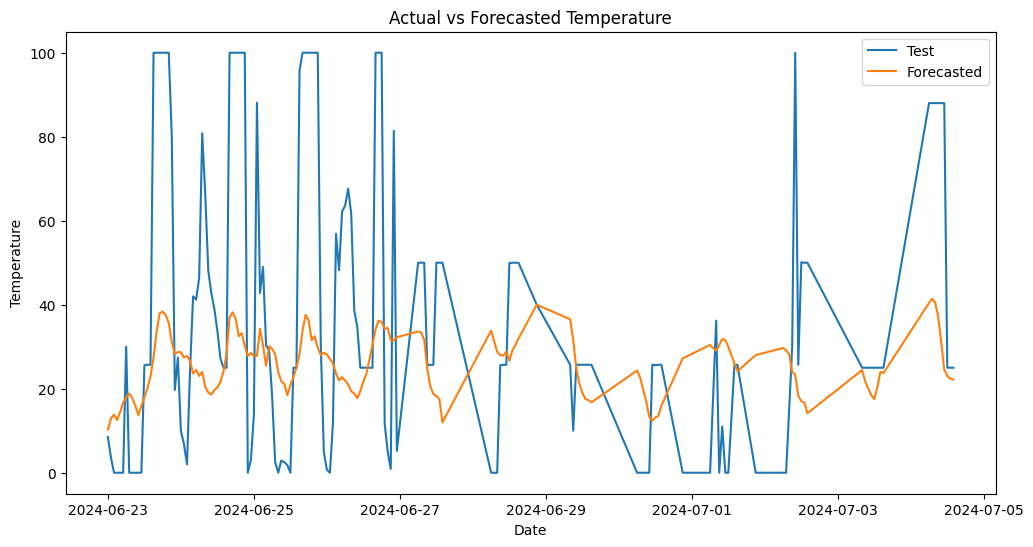

In [8]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
plt.plot(x_test, label='Test')
plt.plot(predictions, label='Forecasted')
plt.title('Actual vs Forecasted Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [9]:
mse = mean_squared_error(x_test, predictions)
ss_res = mse * len(x_test)
ss_tot = ((x_test - x_test.mean()) ** 2).sum()
r_squared = 1 - (ss_res / ss_tot)
print(f" Our model can explain the {round(r_squared, 10)* 100}% of total variability","\n","Root Mean Squared Error = ", np.sqrt(mse))

 Our model can explain the 3.27946743% of total variability 
 Root Mean Squared Error =  32.830338500124654
